# Binary Grading with QD Refinement

**Pipeline:**
1. Load data & parse rubrics
2. Generate initial QDs per question
3. Grade all responses (baseline + QD)
4. Analyze: Did QDs increase inconsistency?
5. Refine QDs for objectivity
6. Re-grade with refined QDs
7. Compare all versions

In [23]:
import time, json, requests, re
from pathlib import Path
from datetime import datetime
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_URL = "http://ece-nebula16.eng.uwaterloo.ca:11434"
NUM_ITERATIONS = 20
CHECKPOINT_DIR = Path('./checkpoints')
QD_DIR = Path('./quality_dimensions')
REFINED_QD_DIR = Path('./refined_qds')
for d in [CHECKPOINT_DIR, QD_DIR, REFINED_QD_DIR]:
    d.mkdir(exist_ok=True)
sns.set_style('whitegrid')

In [24]:
def call_llm(prompt: str, delay: float = 1.0) -> str:
    if delay > 0: time.sleep(delay)
    try:
        r = requests.post(f"{BASE_URL}/api/generate",
                         json={"model": "gpt-oss:120b", "prompt": prompt, "stream": False},
                         timeout=60)
        return r.json().get("response", "") if r.status_code == 200 else f"ERROR_{r.status_code}"
    except Exception as e:
        return f"ERROR_{e}"

def parse_binary(response: str) -> int:
    r = response.lower().strip()
    if 'pass' in r and 'fail' not in r: return 1
    if 'fail' in r and 'pass' not in r: return 0
    if '1' in r: return 1
    if '0' in r: return 0
    return -1

## Step 1: Load Data & Parse Rubrics

In [25]:
def parse_rubric_file(filepath: str) -> list[dict]:
    """Parse a rubric text file into per-question entries."""
    content = Path(filepath).read_text()

    sections = re.split(r"\n\s*QUESTION\s*\n", content, flags=re.IGNORECASE)
    sections = [section.strip() for section in sections if section.strip()]

    rubrics: list[dict] = []
    for section in sections:
        parts = re.split(r"\n\s*The rubric is:\s*\n", section, maxsplit=1, flags=re.IGNORECASE)
        if len(parts) != 2:
            continue

        intro_text, rubric_body = parts[0].strip(), parts[1].strip()
        intro_lines = [line.strip() for line in intro_text.splitlines() if line.strip()]
        question_text = intro_lines[-1] if intro_lines else ""

        meets_match = re.search(
            r"Meets\s+Expectation:?\s*(.*?)(?=\n\s*(?:Does\s+Not?\s+Meet|Doesn['’]t\s+Meet)|\Z)",
            rubric_body,
            flags=re.IGNORECASE | re.DOTALL,
        )
        not_meets_match = re.search(
            r"(Does\s+Not?\s+Meet\s+Expectation|Doesn['’]t\s+Meet\s+Expectation):?\s*(.*)",
            rubric_body,
            flags=re.IGNORECASE | re.DOTALL,
        )

        rubrics.append(
            {
                "question_text": question_text,
                "meets_expectation": meets_match.group(1).strip() if meets_match else "",
                "does_not_meet": not_meets_match.group(2).strip() if not_meets_match else "",
                "raw_text": section,
            }
        )

    return rubrics


In [26]:

# Load all rubrics
rubric_files = {
    1: './Rubrics/rubric_lab1 1.txt',
    2: './Rubrics/rubric_lab2 1.txt',
    3: './Rubrics/rubric_lab3 1.txt',
    4: './Rubrics/rubric_lab4 1.txt',
    5: './Rubrics/rubric_lab5 1.txt'
}

lab_rubrics = {}
for lab_num, filepath in rubric_files.items():
    lab_rubrics[lab_num] = parse_rubric_file(filepath)
    print(f"Lab {lab_num}: {len(lab_rubrics[lab_num])} questions")

print("\nSample rubric (Lab 1, Question 1):")
print(f"Question: {lab_rubrics[1][0]['question_text'][:100]}...")
print(f"Meets: {lab_rubrics[1][0]['meets_expectation'][:100]}...")
print(f"Does not meet: {lab_rubrics[1][0]['does_not_meet'][:100]}...")


Lab 1: 5 questions
Lab 2: 5 questions
Lab 3: 5 questions
Lab 4: 5 questions
Lab 5: 5 questions

Sample rubric (Lab 1, Question 1):
Question: You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab r...
Meets: Students correctly identify that the HAL is the Hardware Abstraction Layer. Students correctly ident...
Does not meet: The student work either contains errors, omissions, or is not written with sufficient detail....


In [27]:
df = pd.read_csv('./bad_questions.csv', delimiter='\t')

questions = {}
for (lab, q_num), group in df.groupby(['lab_number', 'question_number']):
    qid = f"L{lab}Q{q_num}"
    unique_responses = group.drop_duplicates(subset='question_text')
    
    # Get rubric for this question
    rubric_data = None
    if lab in lab_rubrics and q_num <= len(lab_rubrics[lab]):
        rubric_data = lab_rubrics[lab][q_num - 1]
    
    questions[qid] = {
        'lab_number': lab,
        'question_number': q_num,
        'question_text': rubric_data['question_text'] if rubric_data else f"Lab {lab}, Question {q_num}",
        'rubric': rubric_data if rubric_data else None,
        'responses': [
            {'response_id': f"R{i}", 'text': text}
            for i, text in enumerate(unique_responses['question_text'], 1)
        ]
    }

print(f"\nLoaded {len(questions)} questions with rubrics")
for qid, data in list(questions.items()):
    print(f"  {qid}: {len(data['responses'])} responses, rubric={'✓' if data['rubric'] else '✗'}")


Loaded 25 questions with rubrics
  L1Q1: 12 responses, rubric=✓
  L1Q2: 14 responses, rubric=✓
  L1Q3: 18 responses, rubric=✓
  L1Q4: 28 responses, rubric=✓
  L1Q5: 21 responses, rubric=✓
  L2Q1: 20 responses, rubric=✓
  L2Q2: 23 responses, rubric=✓
  L2Q3: 24 responses, rubric=✓
  L2Q4: 30 responses, rubric=✓
  L2Q5: 20 responses, rubric=✓
  L3Q1: 6 responses, rubric=✓
  L3Q2: 3 responses, rubric=✓
  L3Q3: 18 responses, rubric=✓
  L3Q4: 17 responses, rubric=✓
  L3Q5: 10 responses, rubric=✓
  L4Q1: 24 responses, rubric=✓
  L4Q2: 10 responses, rubric=✓
  L4Q3: 23 responses, rubric=✓
  L4Q4: 4 responses, rubric=✓
  L4Q5: 13 responses, rubric=✓
  L5Q1: 14 responses, rubric=✓
  L5Q2: 7 responses, rubric=✓
  L5Q3: 8 responses, rubric=✓
  L5Q4: 6 responses, rubric=✓
  L5Q5: 8 responses, rubric=✓


In [28]:
data['rubric']

{'question_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. The question the students had to answer is: The final exercise of this lab had you mix together yielding and time-based pre-emptive context switching. How is it possible for these two mechanisms to work together?',
 'meets_expectation': "Students must mention that context switching in our OS relies on the PendSV handler (or that it relies on an interrupt if they do not specify which one), and that switching between threads uses the same logic or code whether the switch happened pre-emptively or co-operatively. Therefore, how the switch was triggered doesn't matter.",
 'does_not_meet': 'The student work either contains errors or omissions',
 'raw_text': "You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that 

## Step 2: Grading Functions

In [ ]:
def grade_baseline(response_text: str, rubric: str) -> dict:
    prompt = f"""Grade this response as PASS (1) or FAIL (0).

RUBRIC:
{rubric}

STUDENT RESPONSE:
{response_text}

Output: "Grade: [0 or 1]"""
    
    llm_resp = call_llm(prompt)
    return {'grade': parse_binary(llm_resp), 'raw_response': llm_resp,
            'timestamp': datetime.now().isoformat(), 'method': 'baseline'}

def grade_with_qds(response_text: str, rubric: str, qds: list) -> dict:
    qd_text = "\n".join([f"{i+1}. {qd}" for i, qd in enumerate(qds)])
    prompt = f"""Evaluate using quality dimensions.

RUBRIC:
{rubric}

QUALITY DIMENSIONS:
{qd_text}

RESPONSE:
{response_text}

Output:
Dimension 1: [0 or 1]
Dimension 2: [0 or 1]
...
Overall: [0 or 1]"""
    
    llm_resp = call_llm(prompt)
    
    dim_scores = []
    for i in range(len(qds)):
        pattern = re.compile(rf"^\s*dimension\s+{i+1}\s*:\s*(0|1)\b", flags=re.IGNORECASE | re.MULTILINE)
        match = pattern.search(llm_resp)
        if match:
            dim_scores.append(int(match.group(1)))
            continue
        # Fallback: inspect the first line mentioning this dimension
        dimension_lines = [l for l in llm_resp.split('\n') if f"dimension {i+1}".lower() in l.lower()]
        if dimension_lines:
            line = dimension_lines[0]
            line_lower = line.lower()
            if 'pass' in line_lower and 'fail' not in line_lower:
                dim_scores.append(1)
                continue
            if 'fail' in line_lower and 'pass' not in line_lower:
                dim_scores.append(0)
                continue
            digits = re.findall(r'(?:^|[^0-9])(0|1)(?=[^0-9]|$)', line)
            if digits:
                dim_scores.append(int(digits[-1]))
                continue
        dim_scores.append(-1)
    
    overall = -1
    overall_match = re.search(r"overall\s*:\s*([01])", llm_resp, flags=re.IGNORECASE)
    if overall_match:
        overall = int(overall_match.group(1))
    else:
        overall_lines = [l for l in llm_resp.split('\n') if 'overall' in l.lower()]
        if overall_lines:
            line = overall_lines[0]
            line_lower = line.lower()
            if 'pass' in line_lower and 'fail' not in line_lower:
                overall = 1
            elif 'fail' in line_lower and 'pass' not in line_lower:
                overall = 0
            else:
                digits = re.findall(r'(?:^|[^0-9])(0|1)(?=[^0-9]|$)', line)
                if digits:
                    overall = int(digits[-1])
    
    return {
        'grade': overall,
        'dimension_scores': dim_scores,
        'quality_dimensions': list(qds),
        'raw_response': llm_resp,
        'timestamp': datetime.now().isoformat(),
        'method': 'qd'
    }

## Step 3: Generate Initial QDs

In [31]:
def format_rubric(rubric_data):
    """Format rubric for LLM prompts."""
    if not rubric_data:
        return "Pass (1): Demonstrates technical correctness, completeness, and clarity\nFail (0): Otherwise"
    
    return f"""Pass (1): {rubric_data['meets_expectation']}
Fail (0): {rubric_data['does_not_meet']}"""

In [32]:
def generate_qds(question_text: str, rubric: str) -> dict:
    prompt = f"""Generate 3-5 quality dimensions for grading responses.

QUESTION:
{question_text}

RUBRIC:
{rubric}

Requirements:
- Specific and measurable
- Binary evaluable (pass/fail)
- Applicable to any response that address the inital rubric
- Objective criteria

Format:
1. [dimension]
2. [dimension]
..."""
    
    llm_resp = call_llm(prompt)
    dims = []
    for line in llm_resp.split('\n'):
        line = line.strip()
        if line and (line[0].isdigit() or line.startswith('-')):
            dim = line.split('.', 1)[-1].strip().lstrip('- ')
            if dim: dims.append(dim)
    return {'dimensions': dims, 'raw_response': llm_resp,
            'timestamp': datetime.now().isoformat(), 'version': 'initial'}

def save_qds(qid, data, version='initial'):
    path = QD_DIR / f"{qid}_qds.json" if version == 'initial' else REFINED_QD_DIR / f"{qid}_qds_{version}.json"
    path.write_text(json.dumps(data, indent=2))

def load_qds(qid, version='initial'):
    path = QD_DIR / f"{qid}_qds.json" if version == 'initial' else REFINED_QD_DIR / f"{qid}_qds_{version}.json"
    return json.loads(path.read_text()) if path.exists() else None

def generate_all_qds(questions):
    for qid, q_data in questions.items():
        if load_qds(qid):
            print(f"{qid}: Exists")
            continue
        
        print(f"{qid}: Generating...")
        rubric = format_rubric(q_data['rubric'])
        qd_data = generate_qds(q_data['question_text'], rubric)
        save_qds(qid, qd_data)
        print(f"  {len(qd_data['dimensions'])} QDs")

# generate_all_qds(questions)

In [33]:
generate_all_qds(questions)

L1Q1: Generating...
  5 QDs
L1Q2: Generating...
  5 QDs
L1Q3: Generating...
  5 QDs
L1Q4: Generating...
  5 QDs
L1Q5: Generating...
  4 QDs
L2Q1: Generating...
  5 QDs
L2Q2: Generating...
  5 QDs
L2Q3: Generating...
  5 QDs
L2Q4: Generating...
  4 QDs
L2Q5: Generating...
  4 QDs
L3Q1: Generating...
  4 QDs
L3Q2: Generating...
  4 QDs
L3Q3: Generating...
  5 QDs
L3Q4: Generating...
  4 QDs
L3Q5: Generating...
  8 QDs
L4Q1: Generating...
  5 QDs
L4Q2: Generating...
  5 QDs
L4Q3: Generating...
  5 QDs
L4Q4: Generating...
  5 QDs
L4Q5: Generating...
  7 QDs
L5Q1: Generating...
  5 QDs
L5Q2: Generating...
  5 QDs
L5Q3: Generating...
  5 QDs
L5Q4: Generating...
  5 QDs
L5Q5: Generating...
  4 QDs


## Step 4: Grade All Responses

In [ ]:
def save_checkpoint(data, qid, rid):
    (CHECKPOINT_DIR / f"{qid}_{rid}.json").write_text(json.dumps(data, indent=2))

def load_checkpoint(qid, rid):
    path = CHECKPOINT_DIR / f"{qid}_{rid}.json"
    return json.loads(path.read_text()) if path.exists() else None

def is_complete(ckpt, phase, n):
    return ckpt and len(ckpt.get(f'{phase}_iterations', [])) == n

def grade_all(questions, n=20):
    total = sum(len(q['responses']) for q in questions.values())
    done = 0
    
    for qid, q_data in questions.items():
        print(f"\n{qid}")
        qd_data = load_qds(qid)
        if not qd_data:
            print("  No QDs!")
            continue
        
        qds = qd_data['dimensions']
        rubric = format_rubric(q_data['rubric'])
        
        for resp in q_data['responses']:
            rid, text = resp['response_id'], resp['text']
            ckpt = load_checkpoint(qid, rid) or {
                'question_id': qid, 'response_id': rid, 'response_text': text,
                'baseline_iterations': [], 'qd_initial_iterations': []
            }
            
            if is_complete(ckpt, 'baseline', n) and is_complete(ckpt, 'qd_initial', n):
                done += 1
                continue
            
            print(f"  {rid}")
            
            # Baseline
            for i in range(n - len(ckpt['baseline_iterations'])):
                ckpt['baseline_iterations'].append(grade_baseline(text, rubric))
                if (i+1) % 5 == 0: save_checkpoint(ckpt, qid, rid)
            save_checkpoint(ckpt, qid, rid)
            
            # QD initial
            for i in range(n - len(ckpt['qd_initial_iterations'])):
                ckpt['qd_initial_iterations'].append(grade_with_qds(text, rubric, qds))
                if (i+1) % 5 == 0: save_checkpoint(ckpt, qid, rid)
            save_checkpoint(ckpt, qid, rid)
            
            done += 1
            print(f"    Done ({done}/{total})")



In [231]:
subset_ids = ["L3Q2"]
subset = {qid: questions[qid] for qid in subset_ids}
subset

subest_responses = {qid: questions[qid]['responses'] for qid in subset_ids}

In [97]:
grade_all(subset, n=NUM_ITERATIONS)


L3Q2
  R1
    Done (1/3)
  R2
    Done (2/3)
  R3
    Done (3/3)


## Step 5: Analyze Performance

In [244]:
subset

{'L3Q2': {'lab_number': 3,
  'question_number': 2,
  'question_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. In your own words, explain why you cannot use an #include directive to on a *.c file.',
  'rubric': {'question_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. In your own words, explain why you cannot use an #include directive to on a *.c file.',
   'meets_expectation': 'Students correctly identify that including a .c file can cause errors with multiple definitions in the executable.',
   'does_not_meet': 'The student work either contains errors or omissions.',
   'raw_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to st

In [287]:
def analyze():
    rows = []
    for f in CHECKPOINT_DIR.glob('*.json'):
        d = json.loads(f.read_text())
        bl = [x['grade'] for x in d['baseline_iterations'] if x['grade'] != -1]
        qd = [x['grade'] for x in d.get('qd_initial_iterations', []) if x['grade'] != -1]
        qd_refined = [x['grade'] for x in d.get('qd_refined_iterations', []) if x['grade'] != -1]
        if not bl or not qd or not qd_refined:
            continue

        bl_majority = max(sum(bl), len(bl) - sum(bl))
        qd_majority = max(sum(qd), len(qd) - sum(qd))
        bl_consensus = bl_majority / len(bl) * 100
        qd_consensus = qd_majority / len(qd) * 100
        qd_refined_consensus = qd_majority / len(qd_refined) * 100
        flip_change = bl_consensus - qd_consensus
        qd_refined_flip_change = bl_consensus - qd_refined_consensus

        rows.append({
            'question_id': d['question_id'],
            'response_id': d['response_id'],
            'response_text': d['response_text'],
            'baseline_consensus': bl_consensus,
            'qd_consensus': qd_consensus,
            'consensus_delta': qd_consensus - bl_consensus,
            'qd_refined_consensus': qd_refined_consensus,
            'consensus_delta_refined': qd_refined_consensus - bl_consensus,
            'incremental_consensus_delta': qd_refined_consensus - qd_consensus,
            'flip_rate_change': flip_change,
            'qd_refined_flip_rate_change': qd_refined_flip_change,
            'made_worse': flip_change > 0,
            'baseline_majority': 1 if sum(bl) > len(bl) / 2 else 0,
            'qd_majority': 1 if sum(qd) > len(qd) / 2 else 0,
        })

    return pd.DataFrame(rows)

analysis_df = analyze()
if analysis_df.empty:
    print("No responses available for analysis.")
else:
    print(f"QDs made worse: {analysis_df['made_worse'].sum()} / {len(analysis_df)}")
    q_analysis = analysis_df.groupby('question_id').agg({
        'made_worse': ['sum', 'count'],
        'flip_rate_change': 'mean'
    })
    # flip rate change
    # consensus delta
    # incremental consensus delta
    # consensus delta refined
    # qd refined flip rate change
    # made worse
    
    print(q_analysis)
    #improved question ids

QDs made worse: 9 / 18
            made_worse       flip_rate_change
                   sum count             mean
question_id                                  
L1Q1                 4    12        -2.500000
L3Q1                 5     6        20.735294


In [286]:
analysis_df.head()

,question_id,response_id,response_text,baseline_consensus,qd_consensus,consensus_delta,qd_refined_consensus,consensus_delta_refined,incremental_consensus_delta,flip_rate_change,qd_refined_flip_rate_change,made_worse,baseline_majority,qd_majority
0,L1Q1,R4,The HAL is a software layer that provides gene...,85.0,100.0,15.0,100.0,15.0,0.0,-15.0,-15.0,False,1,0
1,L1Q1,R8,The HAL is a hardware abstraction layer. It is...,100.0,95.0,-5.0,95.0,-5.0,0.0,5.0,5.0,True,1,0
2,L1Q1,R11,The hardware abstraction layer (HAL) is a soft...,80.0,100.0,20.0,100.0,20.0,0.0,-20.0,-20.0,False,1,0
3,L3Q1,R1,"First, each file is preprocessed by the compil...",100.0,80.0,-20.0,80.0,-20.0,0.0,20.0,20.0,True,1,1
4,L1Q1,R9,HAL is the Hardware Abstraction Layer is a set...,100.0,100.0,0.0,100.0,0.0,0.0,0.0,0.0,False,1,0


## Step 6: Refine QDs

In [295]:
def refine_qds(qid, q_text, rubric, problematic_responses):
    original = load_qds(qid)
    orig_qds = original['dimensions']
    
    examples = ""
    for i, r in enumerate(problematic_responses[:3], 1):
        examples += f"\nExample {i}:\n{r['response_text']}\n"
        examples += f"Baseline: {r['baseline_majority']}, QD: {r['qd_majority']} (inconsistent)\n"
    
    prompt = f"""
Current QDs cause INCONSISTENT grading on SAME responses.

QUESTION:
{q_text}

RUBRIC:
{rubric}

CURRENT QDs:
{chr(10).join([f"{i+1}. {qd}" for i, qd in enumerate(orig_qds)])}

EXAMPLES OF INCONSISTENT GRADING:
{examples}

These responses may be VALID. 

Generate REFINED QDs that:
1. MORE OBJECTIVE - clear criteria
2. MORE SPECIFIC - measurable
3. EQUALLY APPLICABLE - no answer bias
4. REDUCE INTERPRETATION

DO NOT favor specific responses.
DO focus on objective, verifiable criteria.

Format:
1. [dimension]
2. [dimension]
...
"""
    
    llm_resp = call_llm(prompt)
    dims = []
    for line in llm_resp.split('\n'):
        line = line.strip()
        if line and (line[0].isdigit() or line.startswith('-')):
            dim = line.split('.', 1)[-1].strip().lstrip('- ')
            if dim: dims.append(dim)
    
    return {'dimensions': dims, 'raw_response': llm_resp,
            'timestamp': datetime.now().isoformat(), 'version': 'refined',
            'original_qds': orig_qds}

def refine_all_problematic(analysis_df, questions):
    for qid in analysis_df['question_id'].unique():
        q_data = analysis_df[analysis_df['question_id'] == qid]
        pct_worse = (q_data['made_worse'].sum() / len(q_data)) * 100
        
        if pct_worse < 30:
            continue
        
        print(f"\n{qid}: Refining ({pct_worse:.1f}% worse)")
        prob = q_data[q_data['made_worse']].sort_values('flip_rate_change', ascending=False)
        prob_list = prob[['response_text', 'baseline_majority', 'qd_majority']].to_dict('records')
        
        q_info = questions[qid]
        rubric = format_rubric(q_info['rubric'])
        refined = refine_qds(qid, q_info['question_text'], rubric, prob_list)
        save_qds(qid, refined, version='refined')
        print(f"  Original: {refined['original_qds']}")
        print(f"  Refined:  {refined['dimensions']}")

# refine_all_problematic(analysis_df, questions)

In [296]:
refine_all_problematic(analysis_df, questions)


L1Q1: Refining (33.3% worse)
  Original: ['**Correct Identification of the HAL** – The response explicitly states that HAL stands for *Hardware\u202fAbstraction\u202fLayer* (or provides an equivalent, accurate expansion).', '**Accurate Statement of Primary Purpose** – The response clearly explains that the HAL is used to *simplify* or *abstract* direct hardware access, thereby making code easier to write and read.', '**Inclusion of At Least One Correct Additional Benefit** – The response supplies **one or more** of the following valid benefits: portability across MCU families, improved code maintainability, easier testing/debugging, reduced coupling between application code and hardware, or faster development time.', '**Absence of Factual Errors** – All statements about the HAL’s role, capabilities, or limitations are factually correct.', '**Original Wording (Own Words)** – The answer is written in the student’s own phrasing, not a verbatim copy of textbook or online definitions.']
  

## Step 7: Re-grade with Refined QDs

In [ ]:
def regrade_refined(questions, n=20):
    print(f"questions: {questions}")
    for qid, q_data in questions.items():
        refined = load_qds(qid, version='refined')
        if not refined: continue
        
        print(f"\n{qid}: Re-grading")
        qds = refined['dimensions']
        rubric = format_rubric(q_data['rubric'])
        
        for resp in q_data['responses']:
            rid, text = resp['response_id'], resp['text']
            ckpt = load_checkpoint(qid, rid)
            if not ckpt or is_complete(ckpt, 'qd_refined', n): continue
            
            if 'qd_refined_iterations' not in ckpt:
                ckpt['qd_refined_iterations'] = []
            
            for i in range(n - len(ckpt['qd_refined_iterations'])):
                ckpt['qd_refined_iterations'].append(grade_with_qds(text, rubric, qds))
                if (i+1) % 5 == 0: save_checkpoint(ckpt, qid, rid)
            save_checkpoint(ckpt, qid, rid)

# regrade_refined(questions, NUM_ITERATIONS)

In [277]:
# Re-grade L3Q2 with refined QDs
# Workaround: directly pass just L3Q2 responses rather than all questions
if "L3Q2" in questions:
    mini_question = {
        "L3Q2": {
            **questions["L3Q2"],
            "responses": questions["L3Q2"].get("responses", [])
        }
    }
    regrade_refined(mini_question, NUM_ITERATIONS)
else:
    print("L3Q2 not found in questions dictionary")

questions: {'L3Q2': {'lab_number': 3, 'question_number': 2, 'question_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. In your own words, explain why you cannot use an #include directive to on a *.c file.', 'rubric': {'question_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. In your own words, explain why you cannot use an #include directive to on a *.c file.', 'meets_expectation': 'Students correctly identify that including a .c file can cause errors with multiple definitions in the executable.', 'does_not_meet': 'The student work either contains errors or omissions.', 'raw_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to studen

In [282]:
qid = "L3Q2"

mini_question = {qid: {
    **questions[qid],
    "responses": [
        resp for resp in questions[qid]["responses"]
        
    ],
}}



In [279]:
mini_question

{'L3Q2': {'lab_number': 3,
  'question_number': 2,
  'question_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. In your own words, explain why you cannot use an #include directive to on a *.c file.',
  'rubric': {'question_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. In your own words, explain why you cannot use an #include directive to on a *.c file.',
   'meets_expectation': 'Students correctly identify that including a .c file can cause errors with multiple definitions in the executable.',
   'does_not_meet': 'The student work either contains errors or omissions.',
   'raw_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to st

In [285]:
mini_question
regrade_refined(mini_question, NUM_ITERATIONS)

questions: {'L3Q2': {'lab_number': 3, 'question_number': 2, 'question_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. In your own words, explain why you cannot use an #include directive to on a *.c file.', 'rubric': {'question_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. In your own words, explain why you cannot use an #include directive to on a *.c file.', 'meets_expectation': 'Students correctly identify that including a .c file can cause errors with multiple definitions in the executable.', 'does_not_meet': 'The student work either contains errors or omissions.', 'raw_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to studen

TypeError: 'NoneType' object is not subscriptable

## Step 8: Final Comparison

In [209]:
def compare_all():
    rows = []
    for f in CHECKPOINT_DIR.glob('*.json'):
        d = json.loads(f.read_text())
        bl = [x['grade'] for x in d['baseline_iterations'] if x['grade'] != -1]
        print(f"bl: {bl}")
        qd_i = [x['grade'] for x in d.get('qd_initial_iterations', []) if x['grade'] != -1]
        print(f"qd_i: {qd_i}")
        qd_r = [x['grade'] for x in d.get('qd_refined_iterations', []) if x['grade'] != -1]
        print(f"qd_r: {qd_r}")
        if not bl or not qd_i: continue
        
        bl_flip = 100 - max(sum(bl), len(bl)-sum(bl)) / len(bl) * 100
        qdi_flip = 100 - max(sum(qd_i), len(qd_i)-sum(qd_i)) / len(qd_i) * 100
        qdr_flip = 100 - max(sum(qd_r), len(qd_r)-sum(qd_r)) / len(qd_r) * 100 if qd_r else None
        
        rows.append({
            'question_id': d['question_id'], 'response_id': d['response_id'],
            'baseline_flip_rate': bl_flip, 'qd_initial_flip_rate': qdi_flip,
            'qd_refined_flip_rate': qdr_flip,
            'initial_improvement': bl_flip - qdi_flip,
            'refined_improvement': bl_flip - qdr_flip if qdr_flip else None,
            'refinement_helped': qdi_flip - qdr_flip if qdr_flip else None
        })
    
    df = pd.DataFrame(rows)
    print("\nBaseline: {:.2f}%".format(df['baseline_flip_rate'].mean()))
    print("QD Initial: {:.2f}%".format(df['qd_initial_flip_rate'].mean()))
    refined = df.dropna(subset=['qd_refined_flip_rate'])
    if len(refined) > 0:
        print("QD Refined: {:.2f}%".format(refined['qd_refined_flip_rate'].mean()))
        print("Refinement: {:.2f}pp".format(refined['refinement_helped'].mean()))
    
    summary = df.groupby('question_id').agg({
        'baseline_flip_rate': 'mean', 'qd_initial_flip_rate': 'mean',
        'qd_refined_flip_rate': 'mean'
    }).round(2)
    print("\n", summary)
    
    df.to_csv('final_comparison.csv', index=False)
    summary.to_csv('question_summary.csv')
    return df

comparison_df = compare_all()

bl: [1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
qd_i: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
qd_r: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
bl: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
qd_i: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
qd_r: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
bl: [1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1]
qd_i: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
qd_r: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
bl: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
qd_i: [1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1]
qd_r: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
bl: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
qd_i: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
qd_r: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
bl: [

In [166]:
import json
from pathlib import Path
import pandas as pd

CKPT_DIR = Path("/Users/paniz/Documents/GitHub/Research-Doc/final/checkpoints")

records = []
for ckpt_path in CKPT_DIR.glob("*.json"):
    with ckpt_path.open() as f:
        data = json.load(f)

    for phase in ("baseline_iterations", "qd_initial_iterations", "qd_refined_iterations"):
        for iter_idx, entry in enumerate(data.get(phase, [])):
            records.append({
                "checkpoint": ckpt_path.name,
                "question_id": data.get("question_id"),
                "response_id": data.get("response_id"),
                "phase": phase,
                "iteration": iter_idx,
                "grade": entry.get("grade"),
                "dimension_scores": entry.get("dimension_scores"),
                "raw_response": entry.get("raw_response"),
            })

ckpt_df = pd.DataFrame(records)
print(f"Loaded {len(ckpt_df)} rows")
ckpt_df.head()

Loaded 1175 rows


,checkpoint,question_id,response_id,phase,iteration,grade,dimension_scores,raw_response
0,L1Q1_R4.json,L1Q1,R4,baseline_iterations,0,1,None,Grade: 1
1,L1Q1_R4.json,L1Q1,R4,baseline_iterations,1,1,None,Grade: 1
2,L1Q1_R4.json,L1Q1,R4,baseline_iterations,2,0,None,Grade: 0
3,L1Q1_R4.json,L1Q1,R4,baseline_iterations,3,0,None,Grade: 0
4,L1Q1_R4.json,L1Q1,R4,baseline_iterations,4,1,None,Grade: 1


In [208]:
BEST_QD_REGISTRY_PATH = Path('./refined_qds/best_qd_registry.json')


def load_best_qd_registry() -> dict:
    if BEST_QD_REGISTRY_PATH.exists():
        try:
            return json.loads(BEST_QD_REGISTRY_PATH.read_text())
        except json.JSONDecodeError:
            pass
    return {}


def save_best_qd_registry(registry: dict) -> None:
    BEST_QD_REGISTRY_PATH.write_text(json.dumps(registry, indent=2))


def evaluate_stage(df: pd.DataFrame, stage: str) -> dict | None:
    total = len(df)
    if total == 0:
        return None

    if stage == 'baseline':
        if 'baseline_flip' not in df.columns:
            return None
        flip_rate = float(df['baseline_flip'].mean() * 100)
        avg_consensus = float(df['baseline_consensus'].mean()) if 'baseline_consensus' in df.columns else None
        majority_mismatch = 0
    elif stage == 'qd_initial':
        if 'qd_flip' not in df.columns:
            return None
        flip_rate = float(df['qd_flip'].mean() * 100)
        avg_consensus = float(df['qd_consensus'].mean()) if 'qd_consensus' in df.columns else None
        majority_mismatch = int((df['baseline_majority'] != df['qd_majority']).sum()) if 'qd_majority' in df.columns else None
    elif stage == 'qd_refined':
        required_cols = {'qd_refined_flip', 'qd_refined_majority'}
        if not required_cols.issubset(df.columns):
            return None
        flip_rate = float(df['qd_refined_flip'].mean() * 100)
        avg_consensus = float(df['qd_refined_consensus'].mean()) if 'qd_refined_consensus' in df.columns else None
        majority_mismatch = int((df['baseline_majority'] != df['qd_refined_majority']).sum())
    else:
        return None

    return {
        'stage': stage,
        'flip_rate': flip_rate,
        'majority_mismatch': majority_mismatch,
        'avg_consensus': avg_consensus,
        'sample_size': total,
    }


def update_best_qd(qid: str, candidates: list[dict]) -> dict | None:
    if not candidates:
        return None

    registry = load_best_qd_registry()
    def metric(entry: dict):
        return (
            entry.get('flip_rate', float('inf')),
            entry.get('majority_mismatch', float('inf')) if entry.get('majority_mismatch') is not None else float('inf')
        )

    valid_candidates = [c for c in candidates if c is not None]
    if not valid_candidates:
        return registry.get(qid)

    best_candidate = min(valid_candidates, key=metric)
    current = registry.get(qid)
    if current is None or metric(best_candidate) < metric(current):
        best_candidate = best_candidate | {'updated_at': datetime.now().isoformat()}
        registry[qid] = best_candidate
        save_best_qd_registry(registry)
        return best_candidate
    return current


In [226]:
def refine_all_problematic_updated(analysis_df, questions):
    for qid in analysis_df['question_id'].unique():
        if qid not in questions:
            continue

        q_data = analysis_df[analysis_df['question_id'] == qid]
        stage_candidates = [
            evaluate_stage(q_data, 'baseline'),
            evaluate_stage(q_data, 'qd_initial'),
            evaluate_stage(q_data, 'qd_refined'),
        ]
        best_entry = update_best_qd(qid, stage_candidates)
        if best_entry:
            print(f"{qid}: current best = {best_entry['stage']} (flip_rate={best_entry['flip_rate']:.2f}%, mismatches={best_entry['majority_mismatch']})")

        if 'made_worse' not in q_data.columns or len(q_data) == 0:
            continue

        pct_worse = (q_data['made_worse'].sum() / len(q_data)) * 100
        if pct_worse < 30:
            continue

        print(f"\n{qid}: Refining ({pct_worse:.1f}% worse)")
        prob = q_data[q_data['made_worse']].sort_values('flip_rate_change', ascending=False)
        prob_list = prob[['response_text', 'baseline_majority', 'qd_majority']].to_dict('records')

        q_info = questions[qid]
        rubric = format_rubric(q_info['rubric'])
        refined = refine_qds(qid, q_info['question_text'], rubric, prob_list)
        save_qds(qid, refined, version='refined')
        print(f"  Original: {refined['original_qds']}")
        print(f"  Refined:  {refined['dimensions']}")

refine_all_problematic = refine_all_problematic_updated



In [191]:
analysis_df

,question_id,response_id,response_text,baseline_consensus,qd_consensus,consensus_delta,flip_rate_change,made_worse,baseline_majority,qd_majority,initial_change
0,L1Q1,R4,The HAL is a software layer that provides gene...,85.0,100.000000,15.000000,-15.000000,False,1,0,0
1,L1Q1,R8,The HAL is a hardware abstraction layer. It is...,100.0,95.000000,-5.000000,5.000000,True,1,0,0
2,L1Q1,R11,The hardware abstraction layer (HAL) is a soft...,80.0,100.000000,20.000000,-20.000000,False,1,0,0
3,L3Q1,R1,"First, each file is preprocessed by the compil...",100.0,80.000000,-20.000000,20.000000,True,1,1,0
4,L1Q1,R9,HAL is the Hardware Abstraction Layer is a set...,100.0,100.000000,0.000000,0.000000,False,1,0,0
5,L1Q1,R10,HAL acts as the layer that directly configures...,85.0,100.000000,15.000000,-15.000000,False,1,0,0
6,L1Q1,R5,The HAL is an acronym for hardware abstraction...,100.0,100.000000,0.000000,0.000000,False,1,1,0
7,L3Q1,R6,Multiple *.c files are compiled into a single ...,100.0,95.000000,-5.000000,5.000000,True,1,1,0
8,L1Q1,R2,The HAL is a set of software functions that ma...,70.0,100.000000,30.000000,-30.000000,False,1,0,1
9,L1Q1,R3,The HAL (Hardware Abstraction Layer) is a blac...,100.0,85.000000,-15.000000,15.000000,True,1,1,0


In [225]:
refine_all_problematic(analysis_df, questions)


L1Q1: Refining (41.7% worse)
  Original: ['**Correct Identification of the HAL** – The response explicitly states that HAL stands for *Hardware\u202fAbstraction\u202fLayer* (or provides an equivalent, accurate expansion).', '**Accurate Statement of Primary Purpose** – The response clearly explains that the HAL is used to *simplify* or *abstract* direct hardware access, thereby making code easier to write and read.', '**Inclusion of At Least One Correct Additional Benefit** – The response supplies **one or more** of the following valid benefits: portability across MCU families, improved code maintainability, easier testing/debugging, reduced coupling between application code and hardware, or faster development time.', '**Absence of Factual Errors** – All statements about the HAL’s role, capabilities, or limitations are factually correct.', '**Original Wording (Own Words)** – The answer is written in the student’s own phrasing, not a verbatim copy of textbook or online definitions.']
  

KeyboardInterrupt: 

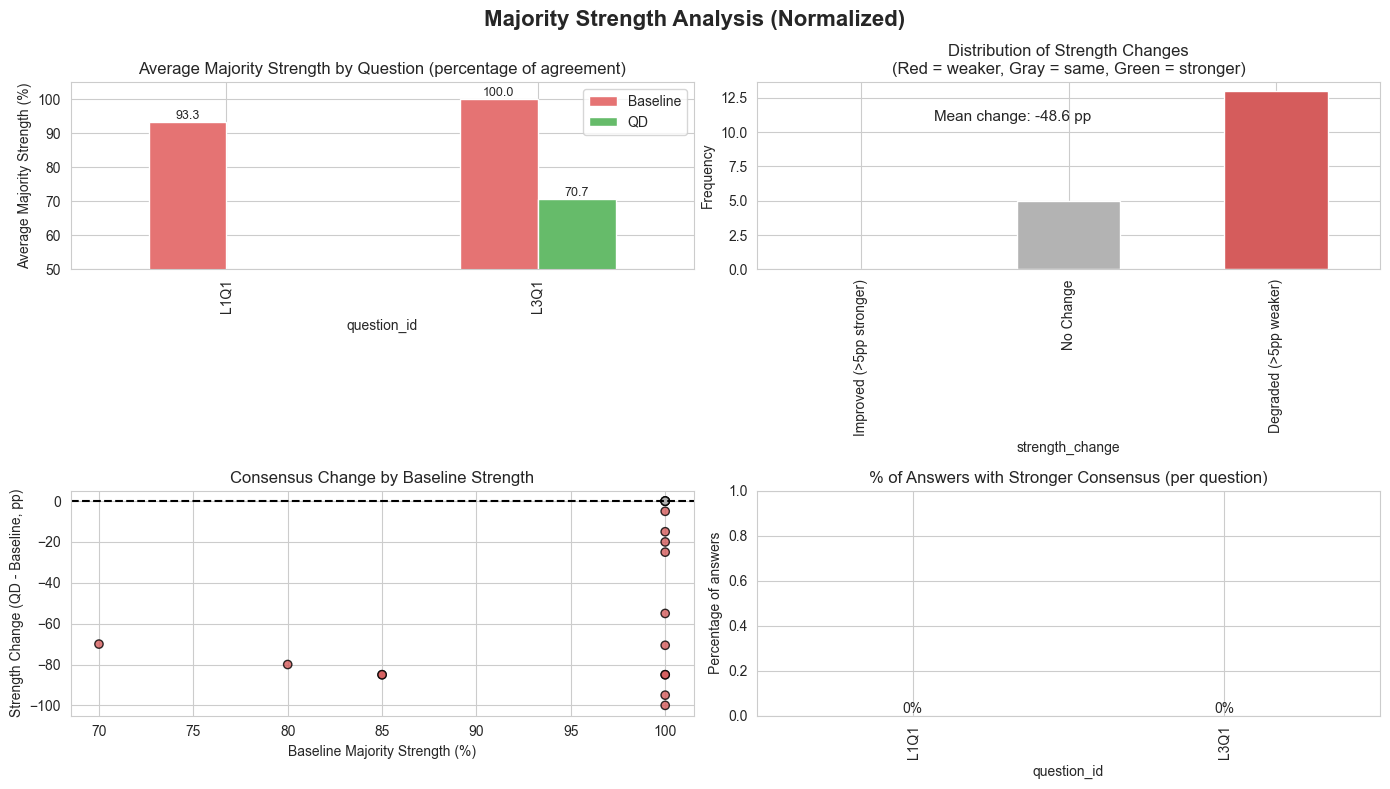

In [206]:
def plot_majority_strength_analysis(df):
    df = df.copy()
    if 'consensus_delta' not in df.columns:
        df['consensus_delta'] = df['qd_consensus'] - df['baseline_consensus']

    grouped = (df.groupby('question_id')[['baseline_consensus', 'qd_consensus']]
               .mean()
               .rename(columns={'baseline_consensus': 'Baseline', 'qd_consensus': 'QD'})
               .sort_index())

    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1, 1.2])

    ax1 = fig.add_subplot(gs[0, 0])
    grouped.plot(kind='bar', ax=ax1, color=['#e57373', '#66bb6a'])
    ax1.set_title('Average Majority Strength by Question (percentage of agreement)')
    ax1.set_ylabel('Average Majority Strength (%)')
    ax1.set_ylim(50, 105)
    for c in ax1.containers:
        ax1.bar_label(c, fmt='%.1f', fontsize=9)

    ax2 = fig.add_subplot(gs[0, 1])
    counts = df.assign(strength_change=np.select(
        [df['consensus_delta'] > 5,
         df['consensus_delta'] < -5],
        ['Improved (>5pp stronger)', 'Degraded (>5pp weaker)'],
        default='No Change'))
    change_order = ['Improved (>5pp stronger)', 'No Change', 'Degraded (>5pp weaker)']
    counts['strength_change'].value_counts().reindex(change_order).plot(
        kind='bar',
        color=['#47b275', '#b3b3b3', '#d55c5c'],
        ax=ax2
    )
    ax2.set_title('Distribution of Strength Changes\n(Red = weaker, Gray = same, Green = stronger)')
    ax2.set_ylabel('Frequency')
    mean_change = df['consensus_delta'].mean()
    ax2.text(0.35, max(1, counts.shape[0] * 0.6), f"Mean change: {mean_change:+.1f} pp", fontsize=11)

    ax3 = fig.add_subplot(gs[1, 0])
    scatter_colors = np.where(
        df['consensus_delta'] > 0, '#47b275',
        np.where(df['consensus_delta'] < 0, '#d55c5c', '#b3b3b3')
    )
    ax3.scatter(df['baseline_consensus'], df['consensus_delta'],
                c=scatter_colors,
                edgecolor='black', alpha=0.8)
    ax3.axhline(0, color='black', linestyle='--')
    ax3.set_title('Consensus Change by Baseline Strength')
    ax3.set_xlabel('Baseline Majority Strength (%)')
    ax3.set_ylabel('Strength Change (QD - Baseline, pp)')

    ax4 = fig.add_subplot(gs[1, 1])
    grouped_change = (
        df.assign(has_improved=df['consensus_delta'] > 0)
          .groupby('question_id')['has_improved']
          .mean()
    )
    grouped_change.plot(kind='bar', ax=ax4, color='#47b275')
    ax4.set_title('% of Answers with Stronger Consensus (per question)')
    ax4.set_ylabel('Percentage of answers')
    ax4.set_ylim(0, 1)
    for c in ax4.containers:
        ax4.bar_label(c, labels=[f"{v * 100:.0f}%" for v in c.datavalues])

    fig.suptitle('Majority Strength Analysis (Normalized)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_majority_strength_analysis(analysis_df)

Flip rate per question (baseline vs QDs vs refined) — percentage of minority votes:


,Baseline minority %,QD minority %,Refined minority %
question_id,,,
L1Q1,6.67,65.00,80.51
L3Q1,0.00,29.26,80.93
L3Q2,NaN,NaN,NaN


Majority stability (share of responses where QD matches baseline majority):


,Initial preserved %,Refined preserved %
question_id,,
L1Q1,33.33,16.67
L3Q1,66.67,16.67
L3Q2,NaN,NaN


Consensus strength (average agreement) and deltas (pp):


,Baseline consensus %,QD consensus %,Refined consensus %,Initial - Baseline Δpp,Refined - Baseline Δpp
question_id,,,,,
L1Q1,93.33,35.00,19.49,-58.33,-73.84
L3Q1,100.00,70.74,19.07,-29.26,-80.93
L3Q2,NaN,NaN,NaN,NaN,NaN


Average minority strength change (pp):


,Baseline minority %,QD minority %,Refined minority %,Initial - Baseline Δpp,Refined - Baseline Δpp
question_id,,,,,
L1Q1,6.67,65.00,80.51,58.33,73.84
L3Q1,0.00,29.26,80.93,29.26,80.93
L3Q2,NaN,NaN,NaN,NaN,NaN


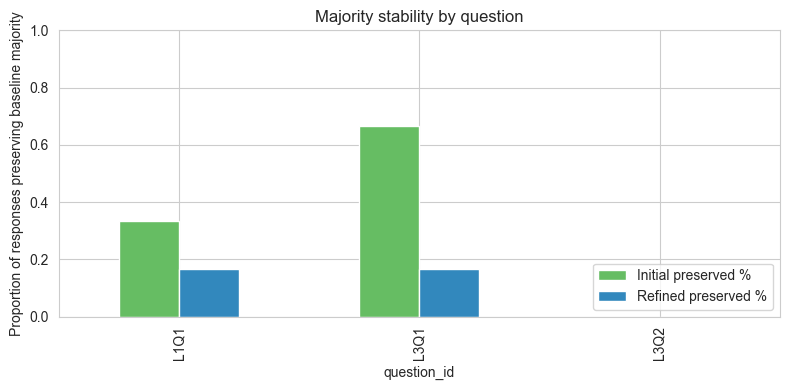

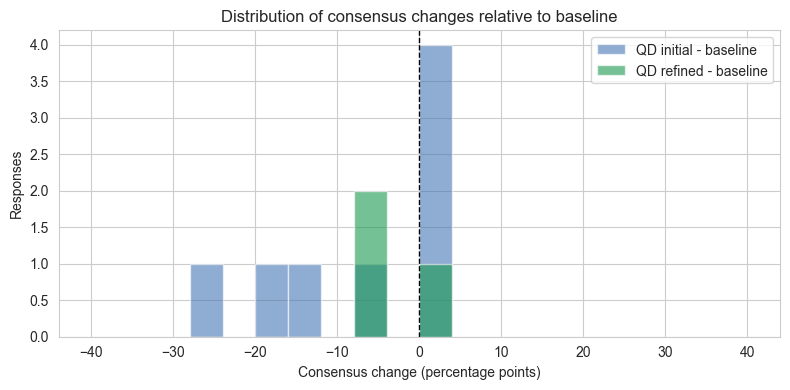

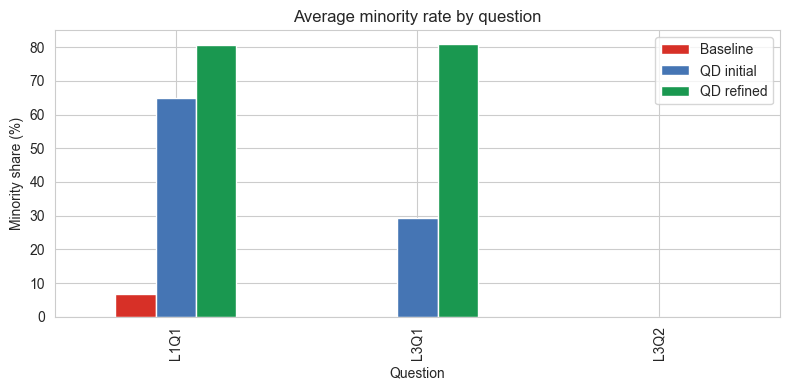

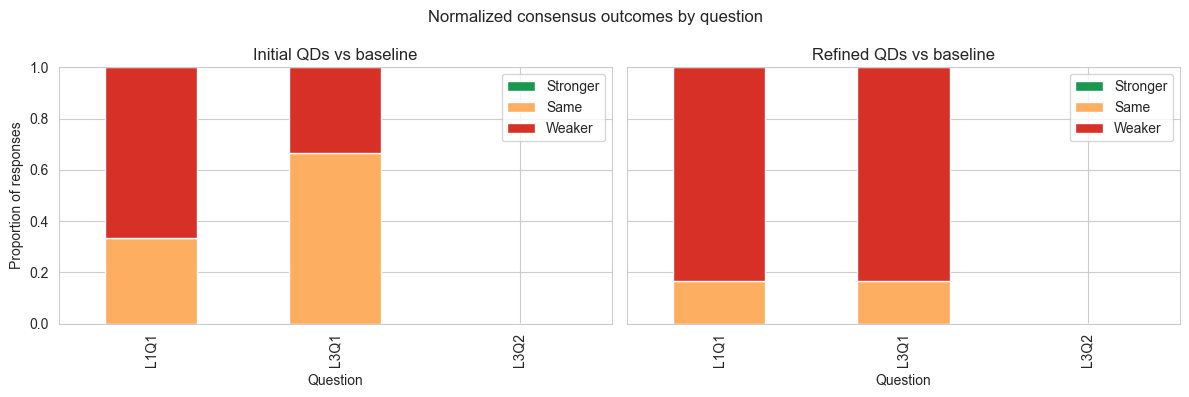

Normalized outcomes table (Initial):


initial_bucket,Stronger,Same,Weaker
question_id,,,
L1Q1,0,0.33,0.67
L3Q1,0,0.67,0.33
L3Q2,0,0.00,0.00


Normalized outcomes table (Refined):


refined_bucket,Stronger,Same,Weaker
question_id,,,
L1Q1,0,0.17,0.83
L3Q1,0,0.17,0.83
L3Q2,0,0.00,0.00


Raw grade counts (per question, per phase):


,question_id,lab,question,responses,baseline_0,baseline_1,qd_init_0,qd_init_1,qd_refined_0,qd_refined_1
0,L1Q1,1,1,12,16,224,156,84,180,46
1,L3Q1,3,1,6,20,100,43,74,96,5
2,L3Q2,3,2,3,3,57,51,9,0,0


In [230]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

SUMMARY_BUCKET = 30.0  # pp threshold for "stronger/weaker" buckets

if 'analysis_df' not in globals():
    raise RuntimeError("Run the analysis cell to build analysis_df before plotting.")

metrics = analysis_df.copy()
metrics['consensus_delta_initial'] = metrics['qd_consensus'] - metrics['baseline_consensus']
metrics['consensus_delta_refined'] = metrics['qd_refined_consensus'] - metrics['baseline_consensus']
metrics['minority_delta_initial'] = metrics['qd_minority'] - metrics['baseline_minority']
metrics['minority_delta_refined'] = metrics['qd_refined_minority'] - metrics['baseline_minority']
metrics['majority_flip_initial'] = np.where(
    metrics['qd_majority'].notna(),
    (metrics['baseline_majority'] != metrics['qd_majority']).astype(float),
    np.nan
)
metrics['majority_flip_refined'] = np.where(
    metrics['qd_refined_majority'].notna(),
    (metrics['baseline_majority'] != metrics['qd_refined_majority']).astype(float),
    np.nan
)
metrics['majority_preserved_initial'] = 1 - metrics['majority_flip_initial']
metrics['majority_preserved_refined'] = 1 - metrics['majority_flip_refined']

if 'grade_counts_df' in globals() and not grade_counts_df.empty:
    all_questions = grade_counts_df['question_id'].tolist()
else:
    all_questions = sorted(metrics['question_id'].unique())

question_summary = (
    metrics.groupby('question_id').agg(
        responses=('response_id', 'nunique'),
        baseline_consensus=('baseline_consensus', 'mean'),
        qd_consensus=('qd_consensus', 'mean'),
        qd_refined_consensus=('qd_refined_consensus', 'mean'),
        baseline_flip_rate=('baseline_minority', 'mean'),
        qd_flip_rate=('qd_minority', 'mean'),
        qd_refined_flip_rate=('qd_refined_minority', 'mean'),
        majority_flip_initial=('majority_flip_initial', 'mean'),
        majority_flip_refined=('majority_flip_refined', 'mean'),
        consensus_delta_initial=('consensus_delta_initial', 'mean'),
        consensus_delta_refined=('consensus_delta_refined', 'mean'),
        minority_delta_initial=('minority_delta_initial', 'mean'),
        minority_delta_refined=('minority_delta_refined', 'mean'),
        majority_preserved_initial=('majority_preserved_initial', 'mean'),
        majority_preserved_refined=('majority_preserved_refined', 'mean'),
    )
    .reindex(all_questions)
)

pct_cols = [
    'baseline_consensus', 'qd_consensus', 'qd_refined_consensus',
    'baseline_flip_rate', 'qd_flip_rate', 'qd_refined_flip_rate',
    'majority_flip_initial', 'majority_flip_refined',
    'majority_preserved_initial', 'majority_preserved_refined'
]
summary_display = question_summary.copy()
summary_display[pct_cols] = summary_display[pct_cols] * 1.0  # keep pp units, convert flips to pct below
summary_display[['majority_flip_initial', 'majority_flip_refined',
                 'majority_preserved_initial', 'majority_preserved_refined']] *= 100
summary_display_round = summary_display.round(2)

print("Flip rate per question (baseline vs QDs vs refined) — percentage of minority votes:")
flip_table = summary_display_round[
    ['baseline_flip_rate', 'qd_flip_rate', 'qd_refined_flip_rate']
].rename(columns={
    'baseline_flip_rate': 'Baseline minority %',
    'qd_flip_rate': 'QD minority %',
    'qd_refined_flip_rate': 'Refined minority %'
})
display(flip_table)

print("Majority stability (share of responses where QD matches baseline majority):")
stability_table = summary_display_round[
    ['majority_preserved_initial', 'majority_preserved_refined']
].rename(columns={
    'majority_preserved_initial': 'Initial preserved %',
    'majority_preserved_refined': 'Refined preserved %'
})
display(stability_table)

print("Consensus strength (average agreement) and deltas (pp):")
consensus_table = summary_display_round[
    ['baseline_consensus', 'qd_consensus', 'qd_refined_consensus',
     'consensus_delta_initial', 'consensus_delta_refined']
].rename(columns={
    'baseline_consensus': 'Baseline consensus %',
    'qd_consensus': 'QD consensus %',
    'qd_refined_consensus': 'Refined consensus %',
    'consensus_delta_initial': 'Initial - Baseline Δpp',
    'consensus_delta_refined': 'Refined - Baseline Δpp'
})
display(consensus_table)

print("Average minority strength change (pp):")
minority_table = summary_display_round[
    ['baseline_flip_rate', 'qd_flip_rate', 'qd_refined_flip_rate',
     'minority_delta_initial', 'minority_delta_refined']
].rename(columns={
    'baseline_flip_rate': 'Baseline minority %',
    'qd_flip_rate': 'QD minority %',
    'qd_refined_flip_rate': 'Refined minority %',
    'minority_delta_initial': 'Initial - Baseline Δpp',
    'minority_delta_refined': 'Refined - Baseline Δpp'
})
display(minority_table)

# --- Majority stability visual ---
fig, ax = plt.subplots(figsize=(8, 4))
bar_data = stability_table.fillna(0) / 100.0
bar_data.plot(kind='bar', ax=ax, color=['#66bd63', '#3288bd'])
ax.set_ylabel('Proportion of responses preserving baseline majority')
ax.set_ylim(0, 1)
ax.set_title('Majority stability by question')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# --- Distribution of consensus changes ---
fig, ax = plt.subplots(figsize=(8, 4))
for series, label, color in [
    (metrics['consensus_delta_initial'], 'QD initial - baseline', '#4575b4'),
    (metrics['consensus_delta_refined'], 'QD refined - baseline', '#1a9850')
]:
    if series.notna().any():
        ax.hist(series.dropna(), bins=np.linspace(-40, 40, 21), alpha=0.6, label=label, color=color)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Consensus change (percentage points)')
ax.set_ylabel('Responses')
ax.set_title('Distribution of consensus changes relative to baseline')
ax.legend()
plt.tight_layout()
plt.show()

# --- Average minority strength by question ---
fig, ax = plt.subplots(figsize=(8, 4))
summary_display_round[
    ['baseline_flip_rate', 'qd_flip_rate', 'qd_refined_flip_rate']
].rename(columns={
    'baseline_flip_rate': 'Baseline',
    'qd_flip_rate': 'QD initial',
    'qd_refined_flip_rate': 'QD refined'
}).plot(kind='bar', ax=ax, color=['#d73027', '#4575b4', '#1a9850'])
ax.set_ylabel('Minority share (%)')
ax.set_title('Average minority rate by question')
ax.set_xlabel('Question')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# --- Normalized outcomes ("1_normalized_outcomes" rerun) ---
def bucket_labels(delta, threshold=SUMMARY_BUCKET):
    return np.select(
        [delta > threshold, delta < -threshold],
        ['Stronger', 'Weaker'],
        'Same'
    )

metrics['initial_bucket'] = np.where(
    metrics['consensus_delta_initial'].notna(),
    bucket_labels(metrics['consensus_delta_initial']),
    np.nan
)
metrics['refined_bucket'] = np.where(
    metrics['consensus_delta_refined'].notna(),
    bucket_labels(metrics['consensus_delta_refined']),
    np.nan
)

def normalized_outcomes(df, col):
    table = (
        pd.crosstab(df['question_id'], df[col], normalize='index')
        .reindex(columns=['Stronger', 'Same', 'Weaker'], fill_value=0)
    )
    return table.reindex(all_questions, fill_value=0)

initial_outcomes = normalized_outcomes(metrics, 'initial_bucket')
refined_outcomes = normalized_outcomes(metrics, 'refined_bucket')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, data, title in zip(
    axes,
    [initial_outcomes, refined_outcomes],
    ['Initial QDs vs baseline', 'Refined QDs vs baseline']
):
    data.plot(kind='bar', stacked=True, ax=ax, color=['#1a9850', '#fdae61', '#d73027'])
    ax.set_xlabel('Question')
    ax.set_ylabel('Proportion of responses')
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend(loc='upper right')
plt.suptitle('Normalized consensus outcomes by question')
plt.tight_layout()
plt.show()

# Provide raw tables for reference
print("Normalized outcomes table (Initial):")
display(initial_outcomes.round(2))
print("Normalized outcomes table (Refined):")
display(refined_outcomes.round(2))

# If grade_counts_df already exists, show it for completeness
if 'grade_counts_df' in globals():
    print("Raw grade counts (per question, per phase):")
    display(grade_counts_df)


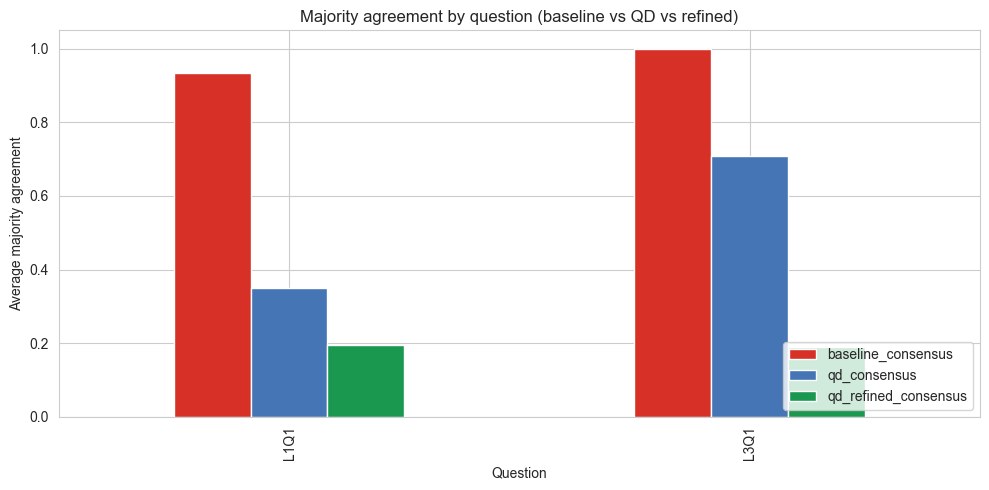

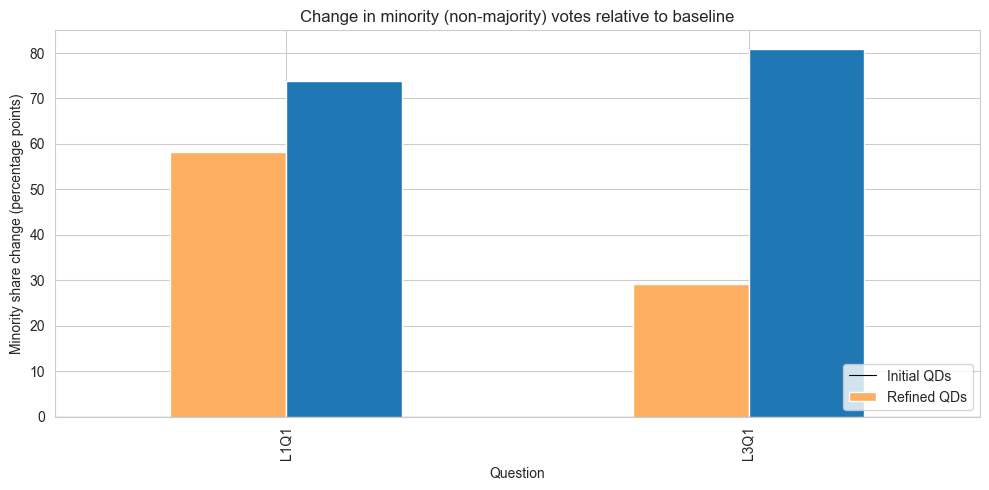

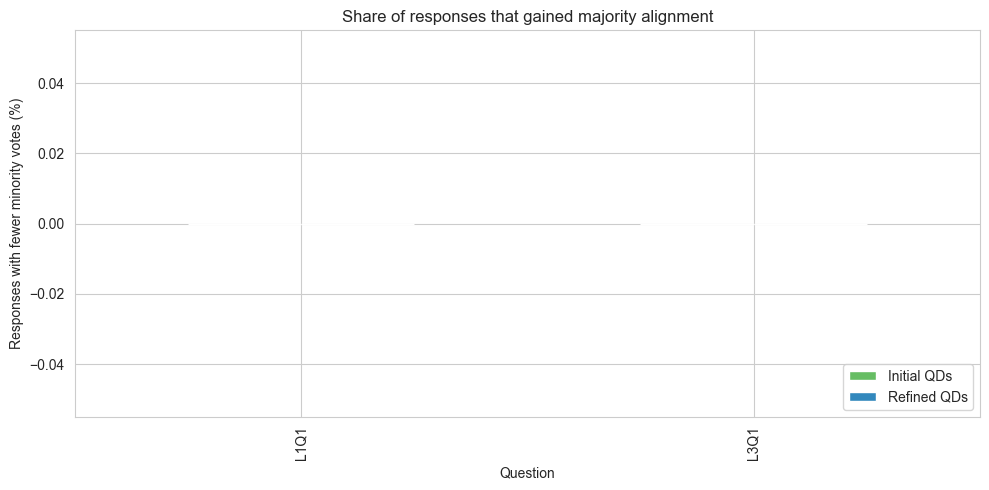

In [215]:
# --- Majority consensus diagnostics ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'analysis_df' not in globals():
    raise RuntimeError("Run the analysis cell to build analysis_df before plotting.")

analysis_df = analysis_df.copy()
analysis_df['consensus_delta_initial'] = analysis_df['qd_consensus'] - analysis_df['baseline_consensus']
analysis_df['consensus_delta_refined'] = analysis_df['qd_refined_consensus'] - analysis_df['baseline_consensus']
analysis_df['minority_delta_initial'] = analysis_df['qd_minority'] - analysis_df['baseline_minority']
analysis_df['minority_delta_refined'] = analysis_df['qd_refined_minority'] - analysis_df['baseline_minority']

question_summary = (
    analysis_df.groupby('question_id').agg(
        responses=('response_id', 'nunique'),
        baseline_consensus=('baseline_consensus', 'mean'),
        qd_consensus=('qd_consensus', 'mean'),
        qd_refined_consensus=('qd_refined_consensus', 'mean'),
        baseline_minority=('baseline_minority', 'mean'),
        qd_minority=('qd_minority', 'mean'),
        qd_refined_minority=('qd_refined_minority', 'mean'),
        minority_delta_initial=('minority_delta_initial', 'mean'),
        minority_delta_refined=('minority_delta_refined', 'mean'),
        improved_initial=('minority_delta_initial', lambda x: (x < 0).mean()),
        improved_refined=('minority_delta_refined', lambda x: (x < 0).mean()),
    )
    .sort_index()
)

# 1) Consensus strength per question (normalized by response count)
consensus_plot = question_summary[['baseline_consensus', 'qd_consensus', 'qd_refined_consensus']] / 100.0
fig, ax = plt.subplots(figsize=(10, 5))
consensus_plot.plot(kind='bar', ax=ax, color=['#d73027', '#4575b4', '#1a9850'])
ax.set_ylabel('Average majority agreement')
ax.set_ylim(0, 1.05)
ax.set_xlabel('Question')
ax.set_title('Majority agreement by question (baseline vs QD vs refined)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 2) Minority share change (lower is better)
minority_plot = question_summary[['minority_delta_initial', 'minority_delta_refined']]
fig, ax = plt.subplots(figsize=(10, 5))
minority_plot.plot(kind='bar', ax=ax, color=['#fdae61', '#1f78b4'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Minority share change (percentage points)')
ax.set_xlabel('Question')
ax.set_title('Change in minority (non-majority) votes relative to baseline')
ax.legend(['Initial QDs', 'Refined QDs'], loc='lower right')
plt.tight_layout()
plt.show()

# 3) Fraction of responses improved (minority decreased)
improvement_plot = question_summary[['improved_initial', 'improved_refined']] * 100
fig, ax = plt.subplots(figsize=(10, 5))
improvement_plot.plot(kind='bar', ax=ax, color=['#66bd63', '#3288bd'])
ax.set_ylabel('Responses with fewer minority votes (%)')
ax.set_xlabel('Question')
ax.set_title('Share of responses that gained majority alignment')
ax.legend(['Initial QDs', 'Refined QDs'], loc='lower right')
plt.tight_layout()
plt.show()


In [214]:
all_questions = sorted(analysis_df['question_id'].unique())
question_summary = question_summary.reindex(all_questions, fill_value=0)